In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor


In [2]:
df = pd.read_csv("/kaggle/input/pakistan-house-price-dataset/zameen-updated.csv")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168446 entries, 0 to 168445
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   property_id    168446 non-null  int64  
 1   location_id    168446 non-null  int64  
 2   page_url       168446 non-null  object 
 3   property_type  168446 non-null  object 
 4   price          168446 non-null  int64  
 5   location       168446 non-null  object 
 6   city           168446 non-null  object 
 7   province_name  168446 non-null  object 
 8   latitude       168446 non-null  float64
 9   longitude      168446 non-null  float64
 10  baths          168446 non-null  int64  
 11  area           168446 non-null  object 
 12  purpose        168446 non-null  object 
 13  bedrooms       168446 non-null  int64  
 14  date_added     168446 non-null  object 
 15  agency         124375 non-null  object 
 16  agent          124374 non-null  object 
 17  Area Type      168446 non-nul

In [3]:
df.isnull().sum()

property_id          0
location_id          0
page_url             0
property_type        0
price                0
location             0
city                 0
province_name        0
latitude             0
longitude            0
baths                0
area                 0
purpose              0
bedrooms             0
date_added           0
agency           44071
agent            44072
Area Type            0
Area Size            0
Area Category        0
dtype: int64

In [4]:
df1 = df.drop(columns = ['agency','agent'],axis=1)

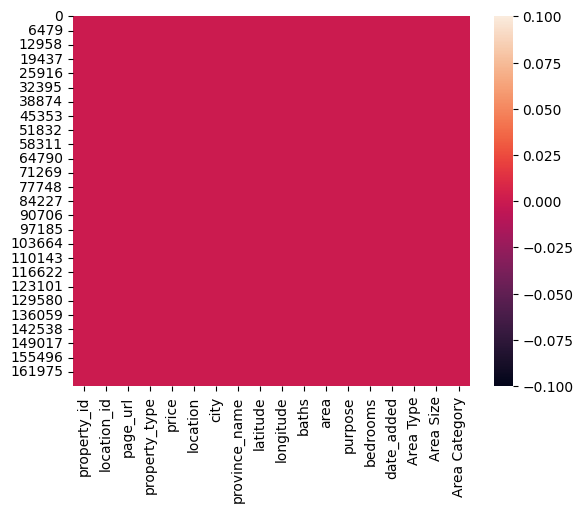

In [5]:
sns.heatmap(df1.isnull())
plt.show()

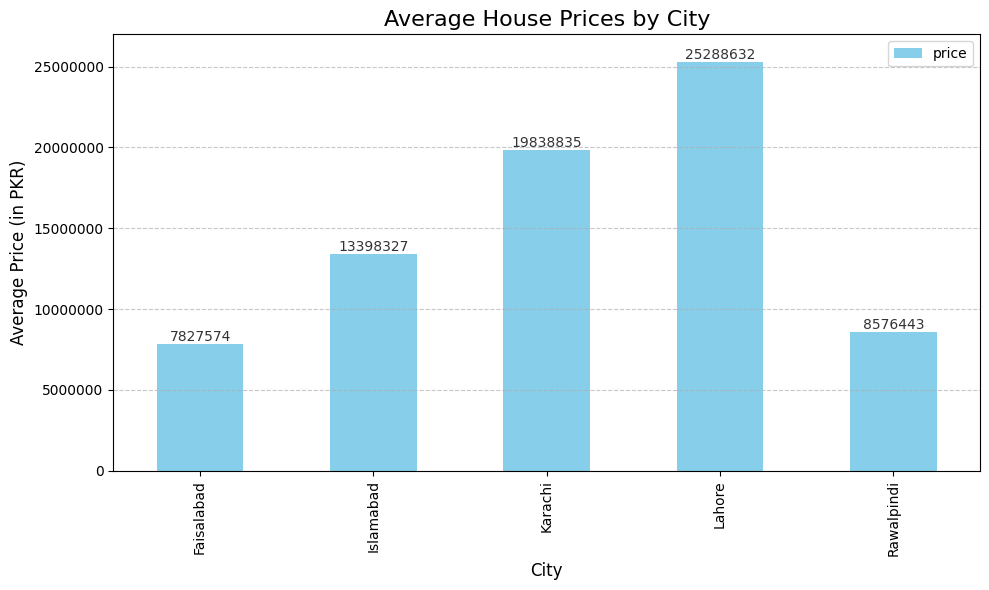

In [6]:
country_price = df1.groupby(['city'])['price'].mean()

plt.figure(figsize=(10,6))
ax = country_price.plot(kind='bar', color='skyblue')
ax.bar_label(ax.containers[0],fontsize=10,fmt='%.0f',label_type='edge',alpha=0.8)
plt.ticklabel_format(style='plain', axis='y')
plt.title("Average House Prices by City", fontsize=16)
plt.xlabel("City", fontsize=12)
plt.ylabel("Average Price (in PKR)", fontsize=12)
plt.ylim(0,27000000)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168446 entries, 0 to 168445
Data columns (total 18 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   property_id    168446 non-null  int64  
 1   location_id    168446 non-null  int64  
 2   page_url       168446 non-null  object 
 3   property_type  168446 non-null  object 
 4   price          168446 non-null  int64  
 5   location       168446 non-null  object 
 6   city           168446 non-null  object 
 7   province_name  168446 non-null  object 
 8   latitude       168446 non-null  float64
 9   longitude      168446 non-null  float64
 10  baths          168446 non-null  int64  
 11  area           168446 non-null  object 
 12  purpose        168446 non-null  object 
 13  bedrooms       168446 non-null  int64  
 14  date_added     168446 non-null  object 
 15  Area Type      168446 non-null  object 
 16  Area Size      168446 non-null  float64
 17  Area Category  168446 non-nul

In [8]:
def convert_to_sqf(row):
    area_size = row['Area Size'] 
    area_type = row['Area Type']
    
    if area_type == "Kanal":
        a = area_size * 20 
        return a * 225
    elif area_type == "Marla":
        return area_size * 225
    else:
        return None
df1["Area_In_Sqft"] = df1.apply(convert_to_sqf, axis=1)
df1.head()

,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,Area Type,Area Size,Area Category,Area_In_Sqft
0,237062,3325,https://www.zameen.com/Property/g_10_g_10_2_gr...,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,4 Marla,For Sale,2,02-04-2019,Marla,4.0,0-5 Marla,900.0
1,346905,3236,https://www.zameen.com/Property/e_11_2_service...,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,5.6 Marla,For Sale,3,05-04-2019,Marla,5.6,5-10 Marla,1260.0
2,386513,764,https://www.zameen.com/Property/islamabad_g_15...,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,8 Marla,For Sale,5,07-17-2019,Marla,8.0,5-10 Marla,1800.0
3,656161,340,https://www.zameen.com/Property/islamabad_bani...,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,2 Kanal,For Sale,4,04-05-2019,Kanal,2.0,1-5 Kanal,9000.0
4,841645,3226,https://www.zameen.com/Property/dha_valley_dha...,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,8 Marla,For Sale,3,07-10-2019,Marla,8.0,5-10 Marla,1800.0


In [9]:
df2 = df1.drop(["location","date_added","latitude","longitude","agency","agent","province_name","area","page_url","location_id","property_id","Area Category","agency"], axis=1, errors='ignore')
print(df2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168446 entries, 0 to 168445
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   property_type  168446 non-null  object 
 1   price          168446 non-null  int64  
 2   city           168446 non-null  object 
 3   baths          168446 non-null  int64  
 4   purpose        168446 non-null  object 
 5   bedrooms       168446 non-null  int64  
 6   Area Type      168446 non-null  object 
 7   Area Size      168446 non-null  float64
 8   Area_In_Sqft   168446 non-null  float64
dtypes: float64(2), int64(3), object(4)
memory usage: 11.6+ MB
None


In [10]:
df2.describe()

,price,baths,bedrooms,Area Size,Area_In_Sqft
count,1.684460e+05,168446.000000,168446.000000,168446.000000,1.684460e+05
mean,1.776576e+07,2.874227,3.179422,5.892188,2.687628e+03
std,3.531003e+07,2.463400,1.971401,5.778327,2.033556e+04
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00
25%,1.750000e+05,0.000000,2.000000,3.000000,1.080000e+03
50%,8.500000e+06,3.000000,3.000000,5.000000,1.597500e+03
75%,1.950000e+07,4.000000,4.000000,8.000000,2.700000e+03
max,2.000000e+09,403.000000,68.000000,800.000000,3.600000e+06


In [11]:
def add_price_per_sqf_column(df, price_col='price', area_col='Area_In_Sqft'):
    df3 = df2.copy()
    df3['price_per_Sqft'] = df3[price_col] / df3[area_col]
    return df3

In [12]:
df3 = add_price_per_sqf_column(df2)
print(df3[['price', 'Area_In_Sqft', 'price_per_Sqft']].head())
# df3.head()

      price  Area_In_Sqft  price_per_Sqft
0  10000000         900.0    11111.111111
1   6900000        1260.0     5476.190476
2  16500000        1800.0     9166.666667
3  43500000        9000.0     4833.333333
4   7000000        1800.0     3888.888889


In [13]:
print(df3.columns)

Index(['property_type', 'price', 'city', 'baths', 'purpose', 'bedrooms',
       'Area Type', 'Area Size', 'Area_In_Sqft', 'price_per_Sqft'],
      dtype='object')


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

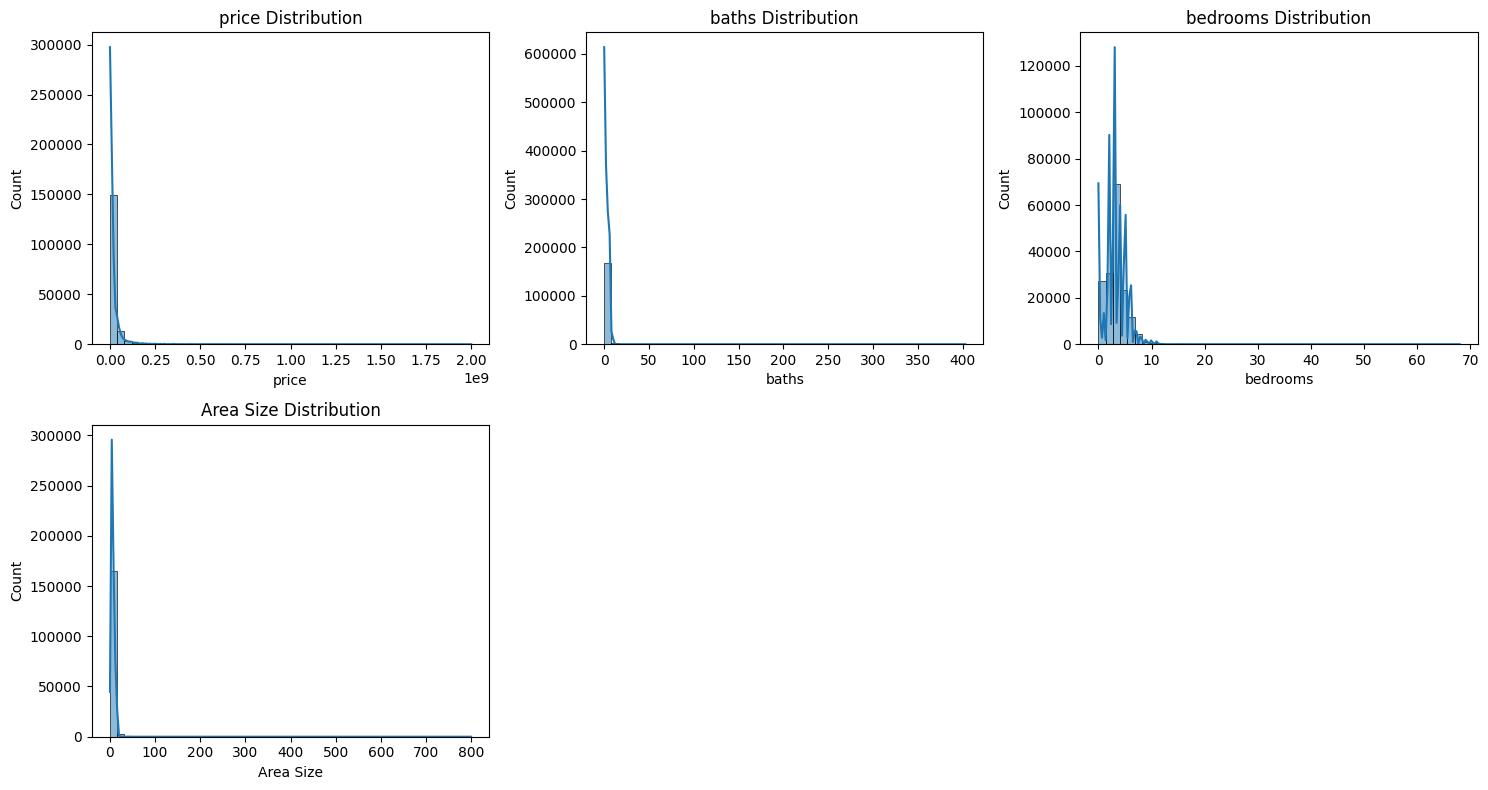

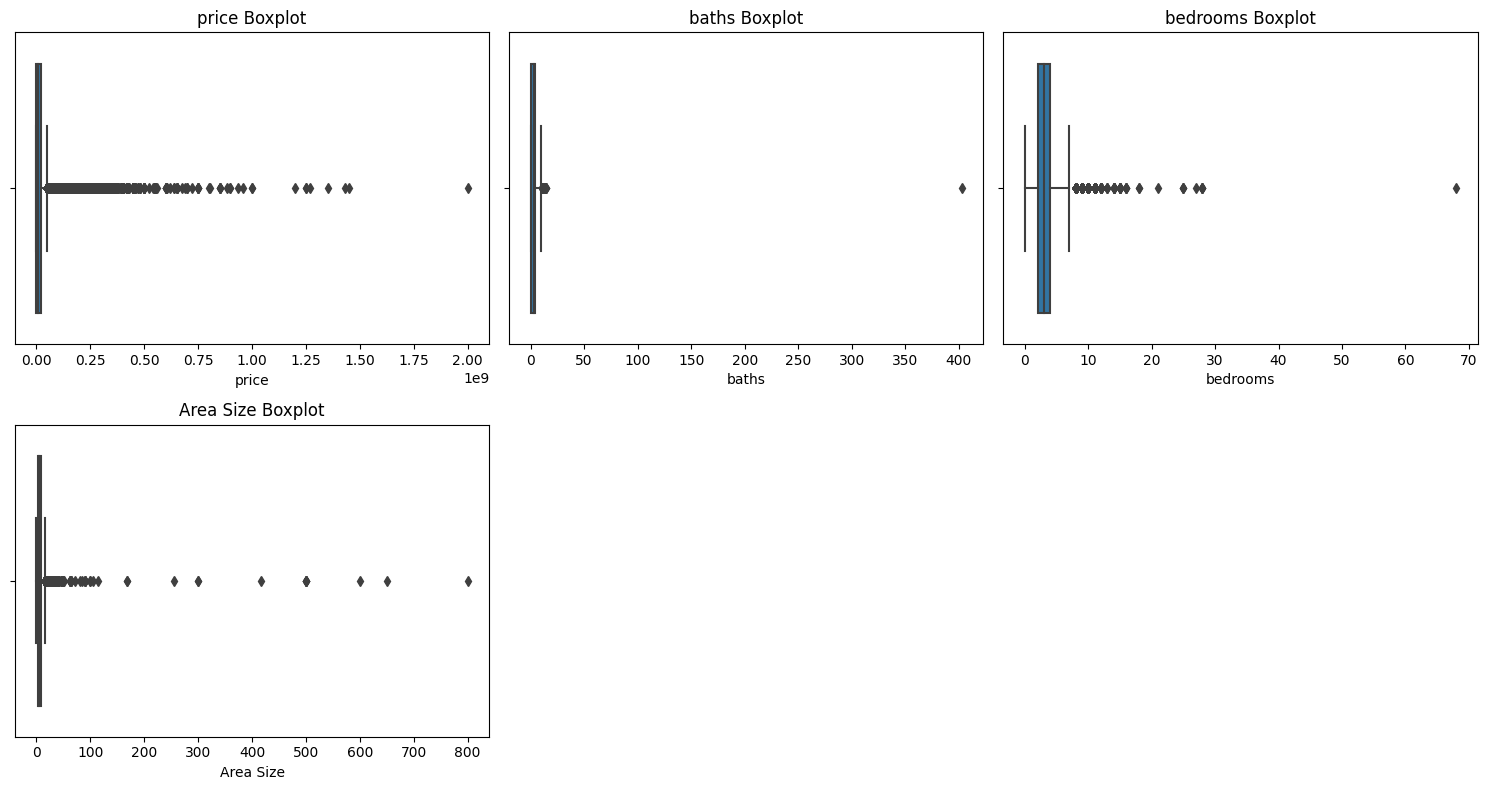

In [14]:

numeric_cols = ['price', 'baths', 'bedrooms', 'Area Size']

# Histograms
plt.figure(figsize=(15, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f'{col} Distribution')
plt.tight_layout()
plt.show()

# Boxplots
plt.figure(figsize=(15, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col])
    plt.title(f'{col} Boxplot')
plt.tight_layout()
plt.show()


In [15]:
def clean_outliers(df):
    df_clean = df3.copy()
    
    # Remove listings with unrealistic prices
    df_clean = df_clean[(df_clean['price'] > 100000) & (df_clean['price'] < 2000000000)]
    
    # Remove unrealistic bathrooms and bedrooms
    df_clean = df_clean[(df_clean['baths'] > 0) & (df_clean['baths'] <= 20)]
    df_clean = df_clean[(df_clean['bedrooms'] > 0) & (df_clean['bedrooms'] <= 20)]
    
    # Remove unrealistic area sizes
    df_clean = df_clean[(df_clean['Area Size'] > 0) & (df_clean['Area Size'] <= 100)]
    df_clean = df_clean[(df_clean['Area_In_Sqft'] > 0) & (df_clean['Area_In_Sqft'] <= 20000)]
    
    return df_clean

df_cleaned = clean_outliers(df)
print("Before Cleaning:", df3.shape)
print("After Cleaning:", df_cleaned.shape)


Before Cleaning: (168446, 10)
After Cleaning: (99774, 10)


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

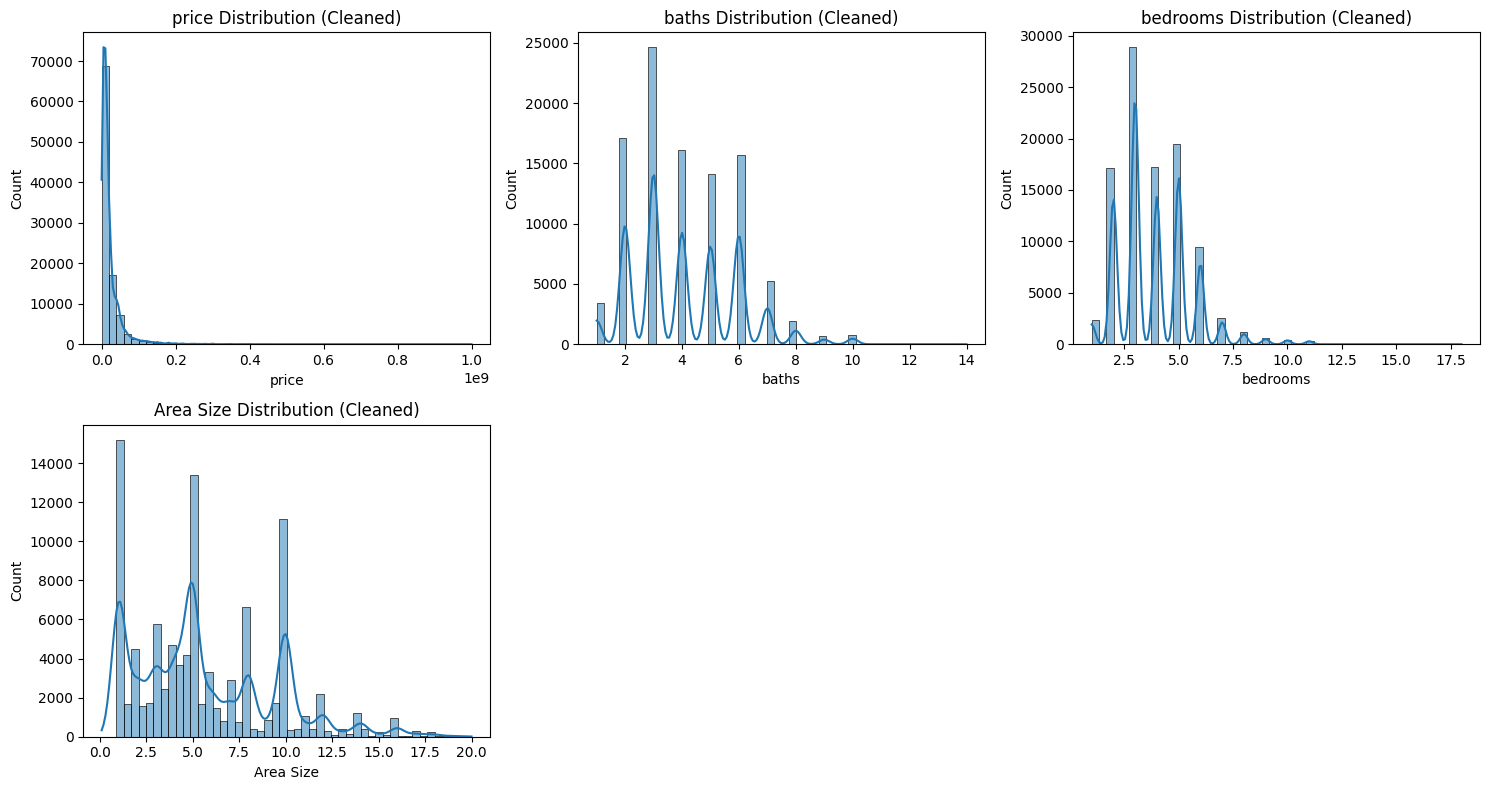

In [16]:
plt.figure(figsize=(15, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_cleaned[col], bins=50, kde=True)
    plt.title(f'{col} Distribution (Cleaned)')
plt.tight_layout()
plt.show()

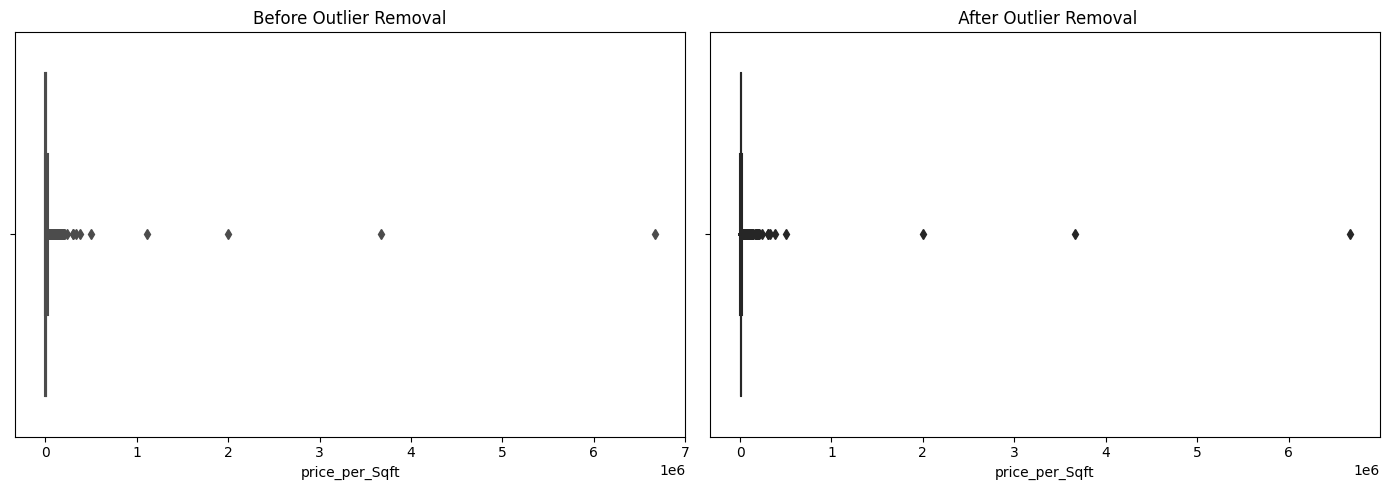

In [17]:

plt.figure(figsize=(14, 5))

# Before
plt.subplot(1, 2, 1)
sns.boxplot(data=df3, x="price_per_Sqft", color="orange")
plt.title("Before Outlier Removal")

# After
plt.subplot(1, 2, 2)
sns.boxplot(data=df_cleaned, x="price_per_Sqft", color="green")
plt.title(" After Outlier Removal")

plt.tight_layout()
plt.show()


In [18]:
df_cleaned.describe()

,price,baths,bedrooms,Area Size,Area_In_Sqft,price_per_Sqft
count,9.977400e+04,99774.000000,99774.000000,99774.000000,99774.000000,9.977400e+04
mean,2.226853e+07,4.082697,3.890513,5.661449,2354.204627,9.536224e+03
std,3.277107e+07,1.804866,1.633142,3.728271,2123.550923,2.585743e+04
min,1.020000e+05,1.000000,1.000000,0.100000,22.500000,8.333333e+00
25%,6.300000e+06,3.000000,3.000000,2.900000,1080.000000,5.925926e+03
50%,1.300000e+07,4.000000,4.000000,5.000000,1755.000000,8.611111e+03
75%,2.500000e+07,5.000000,5.000000,8.000000,2700.000000,1.155556e+04
max,1.000000e+09,14.000000,18.000000,20.000000,19800.000000,6.666667e+06


In [19]:
# Show the shape before and after
print("Before outlier removal:", df3.shape)
print("After outlier removal :", df_cleaned.shape)
print("Removed rows          :", df3.shape[0] - df_cleaned.shape[0])


Before outlier removal: (168446, 10)
After outlier removal : (99774, 10)
Removed rows          : 68672


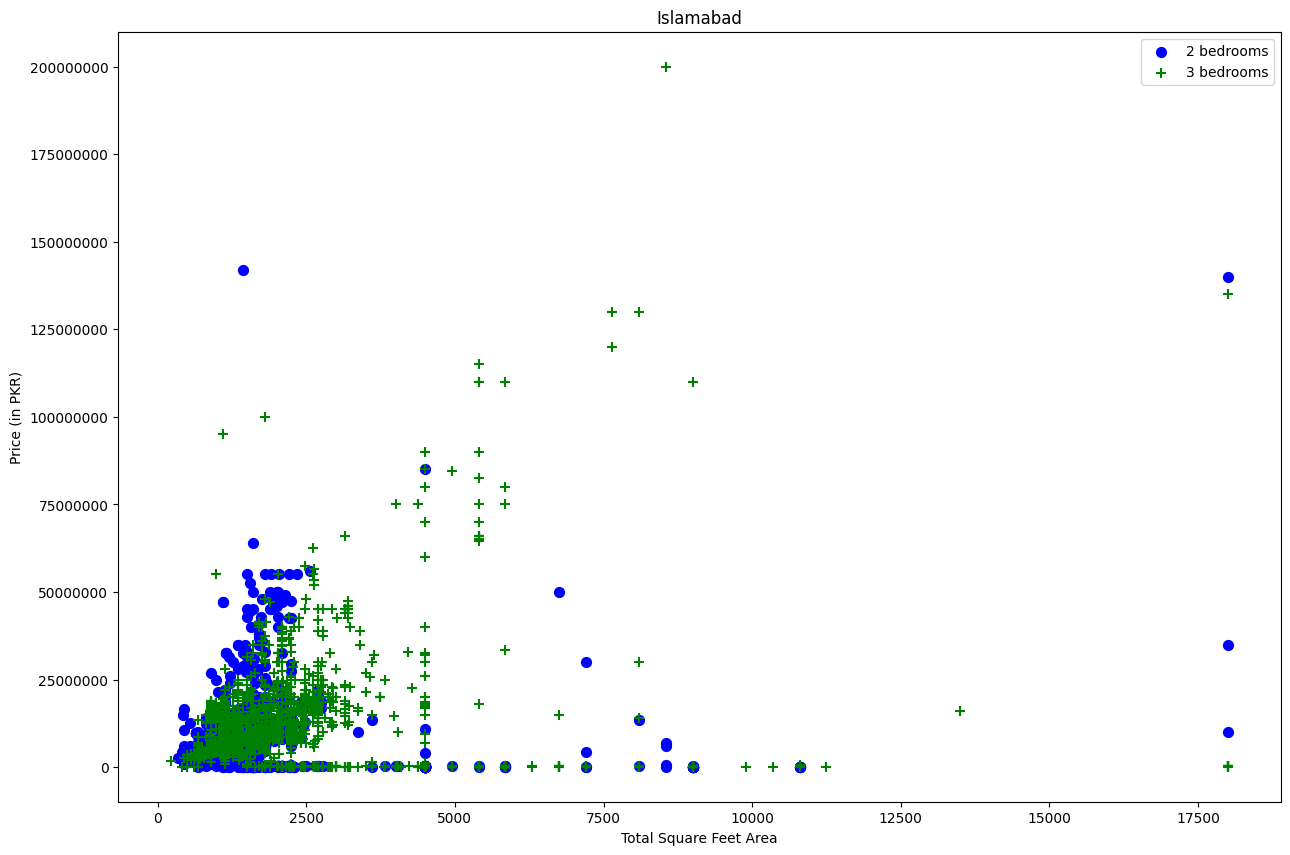

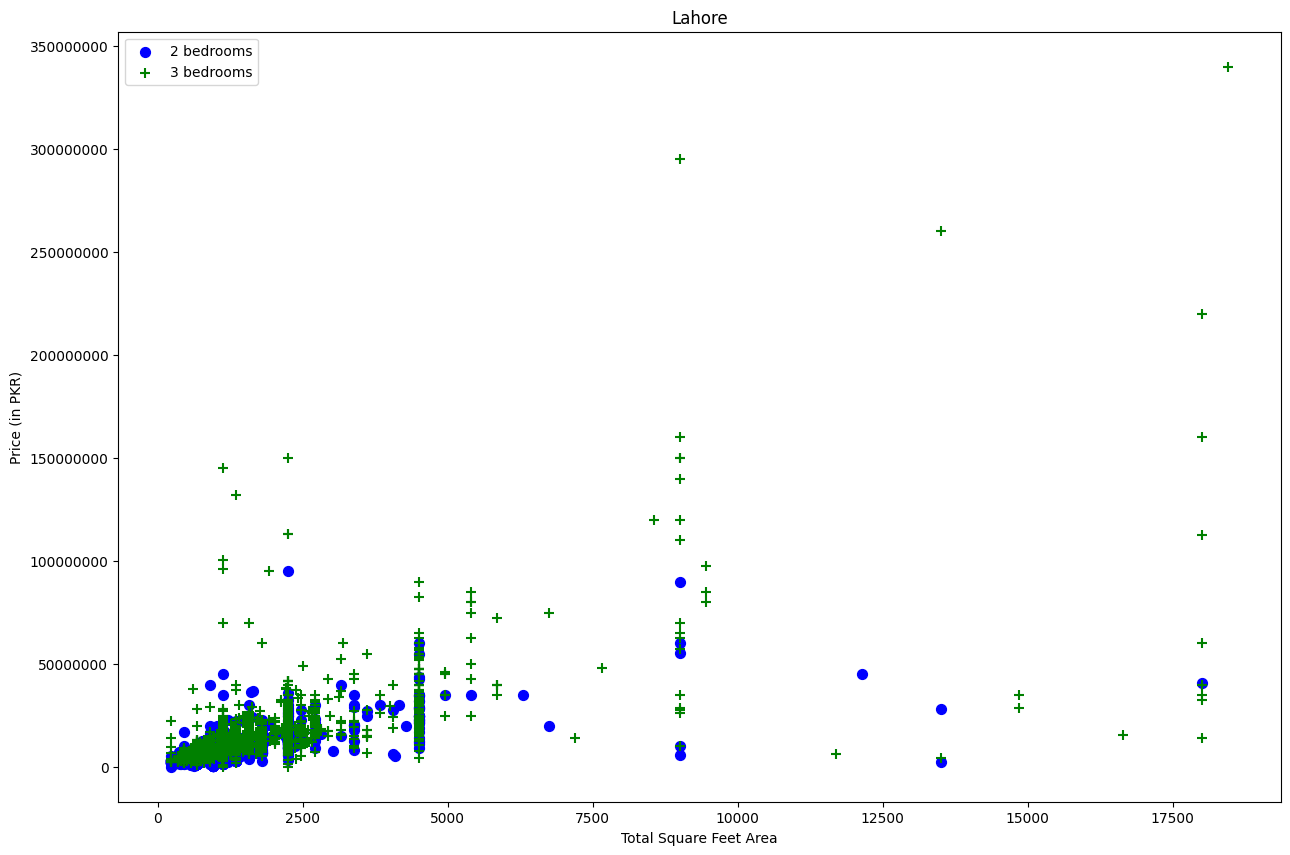

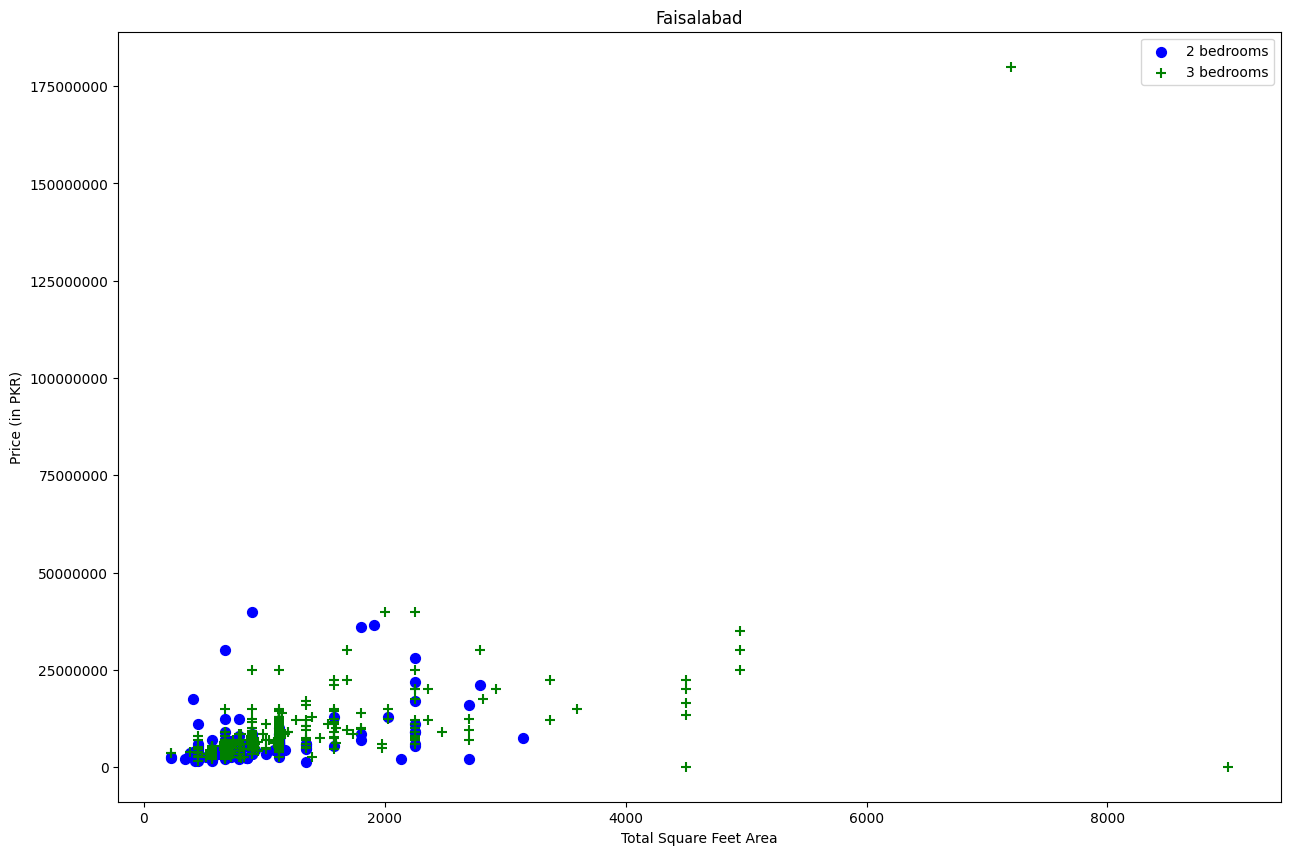

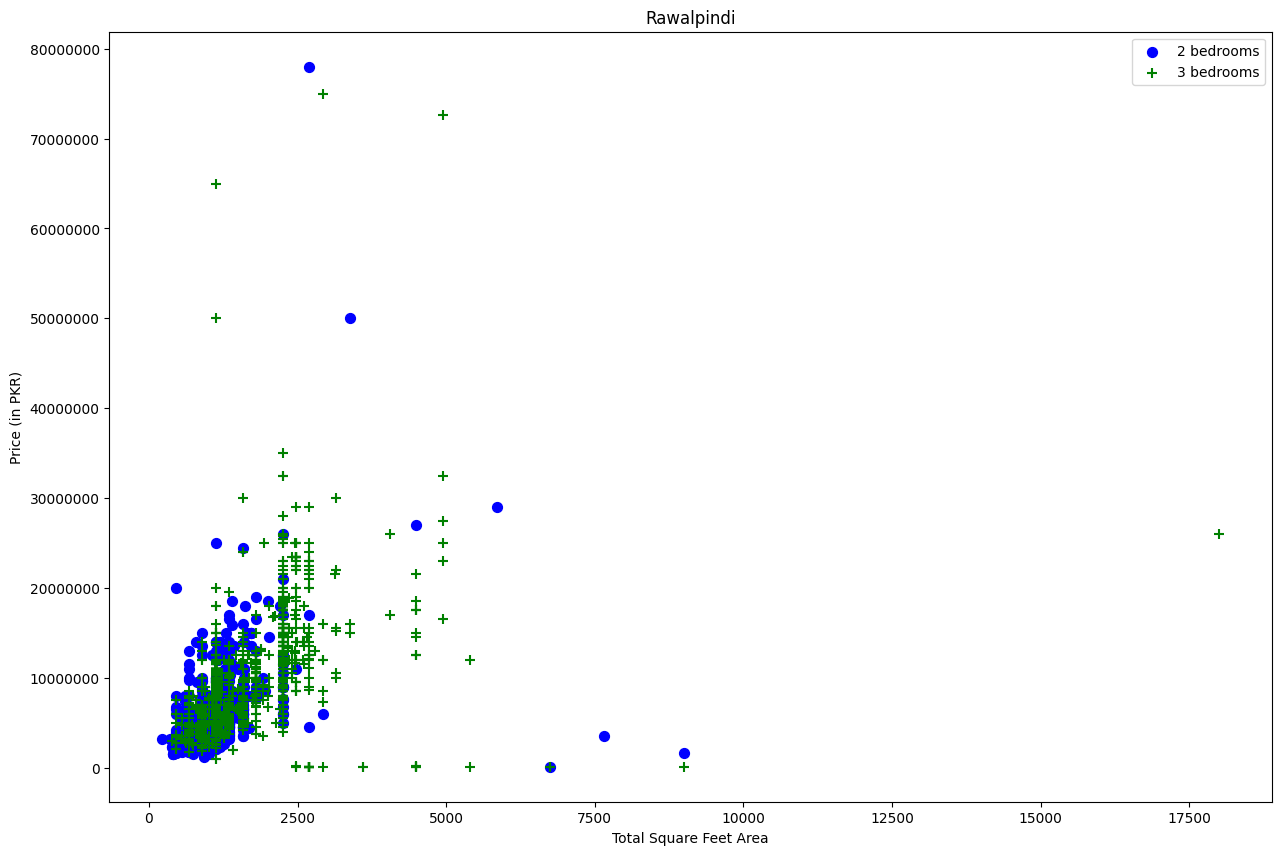

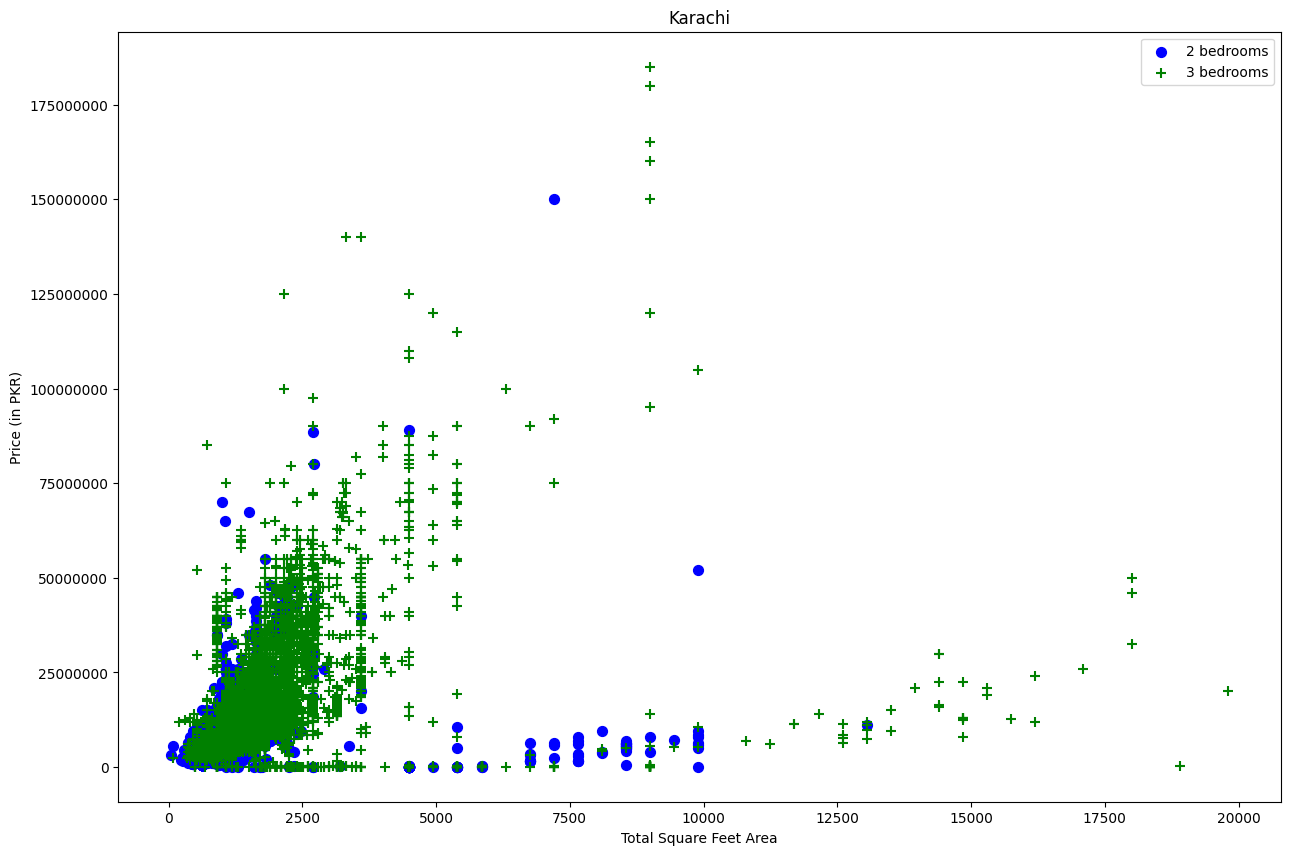

In [20]:
def plot_scatter_chart(df,location):
    bedrooms2 = df[(df.city==location) & (df.bedrooms==2)]
    bedrooms3 = df[(df.city==location) & (df.bedrooms==3)]
    plt.figure(figsize=(15,10))
    plt.scatter(bedrooms2.Area_In_Sqft,bedrooms2.price,color='blue',label='2 bedrooms', s=50)
    plt.scatter(bedrooms3.Area_In_Sqft,bedrooms3.price,marker='+', color='green',label='3 bedrooms', s=50)
    plt.ticklabel_format(style='plain', axis='y')
    plt.xlabel("Total Square Feet Area")
    plt.ylabel("Price (in PKR)")
    plt.title(location)
    plt.legend()
    plt.show()
for i in df_cleaned.city.unique():
    plot_scatter_chart(df_cleaned,i)
    

In [21]:
df_cleaned.head()

,property_type,price,city,baths,purpose,bedrooms,Area Type,Area Size,Area_In_Sqft,price_per_Sqft
0,Flat,10000000,Islamabad,2,For Sale,2,Marla,4.0,900.0,11111.111111
1,Flat,6900000,Islamabad,3,For Sale,3,Marla,5.6,1260.0,5476.190476
2,House,16500000,Islamabad,6,For Sale,5,Marla,8.0,1800.0,9166.666667
3,House,43500000,Islamabad,4,For Sale,4,Kanal,2.0,9000.0,4833.333333
4,House,7000000,Islamabad,3,For Sale,3,Marla,8.0,1800.0,3888.888889


data had been cleaned

In [22]:
categorical_cols = ['property_type', 'city', 'purpose','Area Type']
df4 = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

In [23]:
X = df4.drop('price', axis=1)
y = df4['price']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Normalization complete. Shape of features:", X_scaled.shape)

✅ Normalization complete. Shape of features: (99774, 17)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [25]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R^2:", r2_score(y_test, y_pred))


MSE: 1116799985149.7307
R^2: 0.9989954753797582


In [26]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X_scaled, y, cv=5, scoring='r2')
print("CV R^2 mean:", cv_scores.mean())
print("CV R^2 scores:", cv_scores)


CV R^2 mean: 0.991970786231047
CV R^2 scores: [0.99561717 0.98549752 0.99871491 0.99052224 0.98950209]


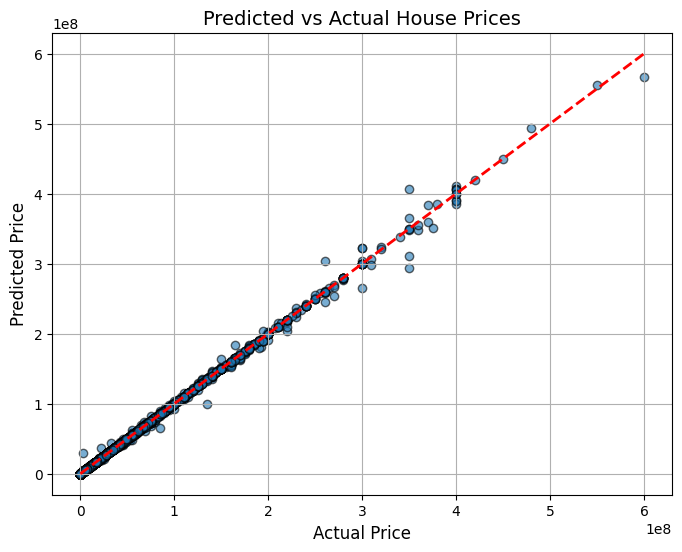

In [27]:
y_pred = rf.predict(X_test)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--', lw=2)

plt.xlabel("Actual Price", fontsize=12)
plt.ylabel("Predicted Price", fontsize=12)
plt.title("Predicted vs Actual House Prices", fontsize=14)
plt.grid(True)
plt.show()

import gradio as gr
import joblib

# === Assume your trained objects ===
# model: Trained RandomForestRegressor
# scaler: Trained StandardScaler
# feature_columns: List of columns in correct order after one-hot encoding
# Save them first if not already:
# joblib.dump(model, "price_model.pkl")
# joblib.dump(scaler, "scaler.pkl")
# joblib.dump(feature_columns, "columns.pkl")

model = joblib.load("y_pred")
scaler = joblib.load("scaler.pkl")
feature_columns = joblib.load("columns.pkl")

# === Input Categories ===
cities = ['Islamabad', 'Lahore', 'Karachi','Faisalabad','Rawalpindi']  # Add all available cities
property_types = ['House', 'Flat', 'Plot']   # Adjust to match your dataset
purposes = ['For Sale', 'For Rent']
area_types = ['Marla', 'Kanal', 'SqFt']      # Adjust as per dataset

# === Prediction Function ===
def predict_price(property_type, city, purpose, area_type, area_size, baths, bedrooms):
    # Build input dataframe
    data = {
        'price_per_Sqft': [0],  # Placeholder if needed
        'baths': [baths],
        'bedrooms': [bedrooms],
        'Area Size': [area_size],
        'Area_In_Sqft': [area_size * (225 if area_type == 'Marla' else (4500 if area_type == 'Kanal' else 1))]
    }
    df_input = pd.DataFrame(data)

    # Add categorical columns
    df_input['property_type'] = property_type
    df_input['city'] = city
    df_input['purpose'] = purpose
    df_input['Area Type'] = area_type

    # One-hot encode
    df_input = pd.get_dummies(df_input, columns=['property_type', 'city', 'purpose', 'Area Type'], drop_first=True)

    # Align columns with training data
    df_input = df_input.reindex(columns=feature_columns, fill_value=0)

    # Scale
    X_scaled = scaler.transform(df_input)

    # Predict
    pred_log = model.predict(X_scaled)[0]
    price = np.expm1(pred_log)  # Reverse log1p
    return f"Predicted Price: PKR {price:,.0f}"

# === Gradio UI ===
with gr.Blocks() as demo:
    gr.Markdown("## 🏡 Pakistan House Price Prediction")

    with gr.Row():
        property_type_in = gr.Dropdown(property_types, label="Property Type")
        city_in = gr.Dropdown(cities, label="City")
        purpose_in = gr.Dropdown(purposes, label="Purpose")
        area_type_in = gr.Dropdown(area_types, label="Area Type")
        area_size_in = gr.Number(label="Area Size")
        baths_in = gr.Number(label="Number of Baths")
        bedrooms_in = gr.Number(label="Number of Bedrooms")

    predict_btn = gr.Button("Predict Price")
    output = gr.Textbox(label="Prediction")

    predict_btn.click(
        fn=predict_price,
        inputs=[property_type_in, city_in, purpose_in, area_type_in, area_size_in, baths_in, bedrooms_in],
        outputs=output
    )

demo.launch()


..........................................................................................................................................